In [4]:
import numpy as np
from Q2 import funcV, rand_gen_data, f_gradV
import time
from scipy.io import loadmat
import pandas as pd


def data_loader(path):
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    train, test = data['train'], data['test']

    return train, test

In [10]:
path = r'..\data\mnist_train_test.mat'
train, test = data_loader(path)

print("train fields:", train._fieldnames)
print("test  fields:", test._fieldnames)
for name in train._fieldnames:
    f = getattr(train, name)
    print(f"  train.{name}: type={type(f)}, shape={getattr(f, 'shape', None)}, dtype={getattr(f, 'dtype', None)}")
for name in test._fieldnames:
    f = getattr(test, name)
    print(f"  test.{name}:  type={type(f)}, shape={getattr(f, 'shape', None)}, dtype={getattr(f, 'dtype', None)}")

train fields: ['X', 'y']
test  fields: ['X', 'y']
  train.X: type=<class 'numpy.ndarray'>, shape=(785, 12665), dtype=float64
  train.y: type=<class 'numpy.ndarray'>, shape=(12665,), dtype=uint8
  test.X:  type=<class 'numpy.ndarray'>, shape=(785, 2115), dtype=float64
  test.y:  type=<class 'numpy.ndarray'>, shape=(2115,), dtype=uint8


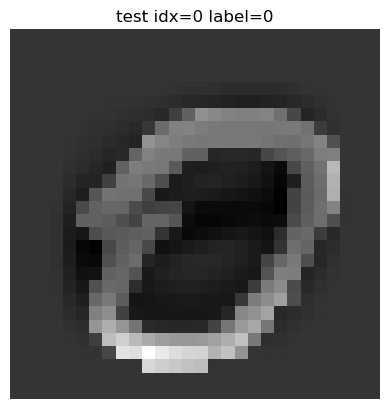

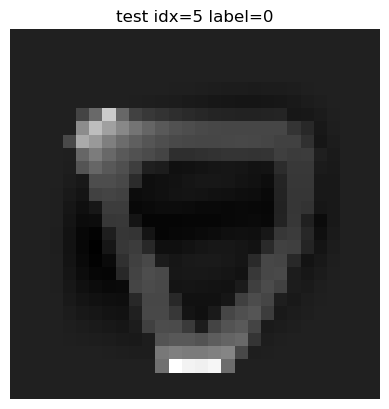

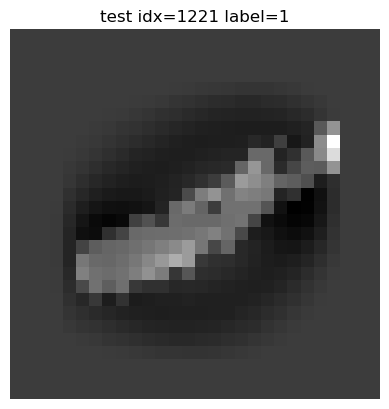

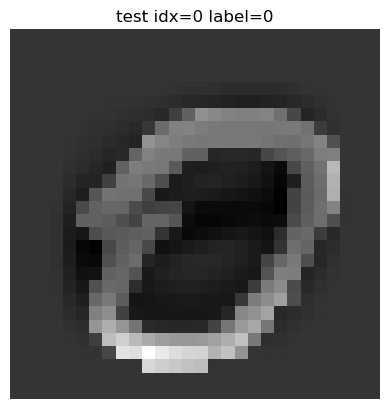

In [11]:
import matplotlib.pyplot as plt

def show(idx, split="test"):
    s = train if split == "train" else test
    # s.X is (785, n). Column idx is image idx.
    # First 784 rows are pixels, last row is the appended 1 (bias).
    img = s.X[:784, idx].reshape(28, 28)
    label = s.y[idx]
    plt.imshow(img, cmap="gray")
    plt.title(f"{split} idx={idx} label={label}")
    plt.axis("off")
    plt.show()

show(0)
show(5)
show(1221)
show(0, split="test")

In [12]:
import pandas as pd
import numpy as np

X_train = train.X[:784].T
X_test  = test.X[:784].T

df_train = pd.DataFrame({
    "pixel_dat": list(X_train),
    "label":     train.y,
    "split":     "train",
})

df_test = pd.DataFrame({
    "pixel_dat": list(X_test),
    "label":     test.y,
    "split":     "test",
})

df = pd.concat([df_train, df_test], ignore_index=True)

print("Sum of isna vlaues is: ", (df['pixel_dat'].isna() + df['label'].isna()).sum())
df.head()

Sum of isna vlaues is:  0


,pixel_dat,label,split
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.00...",0,train
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.00...",1,train
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.00...",1,train
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.00...",0,train
4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.00...",0,train


In [13]:
rng = np.random.default_rng(seed=42)
x = rng.uniform(low=-0.01, high=0.01, size=785)

x = np.asarray(x, dtype='float')
print(x)

[ 5.47912097e-03 -1.22243120e-03  7.17195840e-03  3.94736058e-03
 -8.11645304e-03  9.51244703e-03  5.22279404e-03  5.72128611e-03
 -7.43772735e-03 -9.92281242e-04 -2.58403952e-03  8.53529978e-03
  2.87730240e-03  6.45523227e-03 -1.13171602e-03 -5.45522556e-03
  1.09169574e-03 -8.72365488e-03  6.55262344e-03  2.63328798e-03
  5.16175480e-03 -2.90948064e-03  9.41396049e-03  7.86242243e-03
  5.56766994e-03 -6.10722584e-03 -6.65579925e-04 -9.12392468e-03
 -6.91421016e-03  3.66097906e-03  4.89524312e-03  9.35019465e-03
 -3.48349284e-03 -2.59080588e-03 -6.08883774e-04 -6.21057282e-03
 -7.40156989e-03 -4.85901475e-04 -5.46181302e-03  3.39627989e-03
 -1.25696162e-03  6.65356392e-03  4.00530204e-03 -3.75266717e-03
  6.64519603e-03  6.09528715e-03 -2.25043242e-03 -4.23343792e-03
  3.64991008e-03 -7.20495033e-03 -6.00183595e-03 -9.85275460e-03
  5.73848755e-03  3.29701713e-03  4.10330757e-03  5.61458062e-03
 -8.21684489e-04  1.37482392e-03 -7.20406004e-03 -7.70939853e-03
  3.36805924e-03 -5.78075

In [18]:
import numpy as np
from scipy.io import loadmat

# --- load weights ---
theta = np.load(r'..\results\final_theta.npy')
d = theta.shape[0] - 1

# --- load data ---
data = loadmat('../data/mnist_train_test.mat', squeeze_me=True, struct_as_record=False)
train, test = data['train'], data['test']

X_train = train.X.T
y_train = train.y.astype(float)
X_test  = test.X.T
y_test  = test.y.astype(float)

def accuracy(X, y, theta):
    scores = X @ theta
    preds  = (scores > 0).astype(float)
    return (preds == y).mean(), preds

acc_train, preds_train = accuracy(X_train, y_train, theta)
acc_test,  preds_test  = accuracy(X_test,  y_test,  theta)

print(f"train accuracy: {acc_train*100:.2f}%   (error {1-acc_train:.4f})")
print(f"test  accuracy: {acc_test*100:.2f}%   (error {1-acc_test:.4f})")

train accuracy: 99.86%   (error 0.0014)
test  accuracy: 99.91%   (error 0.0009)
